# LAB 02 — Thí nghiệm mô hình ngôn ngữ

In [1]:
from pathlib import Path
from html import escape
import csv
import gzip
import json
import random
import sys

import pandas as pd
from IPython.display import SVG, display

LAB_DIR = Path.cwd()
if LAB_DIR.name != 'lab02':
    LAB_DIR = LAB_DIR / 'lab02'
PROJECT_DIR = LAB_DIR.parent
sys.path.insert(0, str(LAB_DIR))
from ngram_lm import NGramLanguageModel, count_ngrams, frequency_summary, text_to_sentences

CORPUS_PATH = PROJECT_DIR / 'data' / 'c4-train.00000-of-01024-30K.json.gz'
DOCUMENT_LIMIT = 10_000
SEED = 42


## Nạp corpus

In [2]:
documents = []
with gzip.open(CORPUS_PATH, 'rt', encoding='utf-8') as stream:
    for line in stream:
        if len(documents) >= DOCUMENT_LIMIT:
            break
        record = json.loads(line)
        text = record.get('text', '')
        if isinstance(text, str):
            documents.append(text)

display(pd.DataFrame([{
    'Corpus': CORPUS_PATH.name,
    'Số document đã nạp': len(documents),
}]))


,Corpus,Số document đã nạp
0,c4-train.00000-of-01024-30K.json.gz,10000


## Chia tập theo document

In [3]:
indices = list(range(len(documents)))
random.Random(SEED).shuffle(indices)
train_end = int(len(indices) * 0.8)
validation_end = train_end + int(len(indices) * 0.1)
document_splits = {
    'train': [documents[i] for i in indices[:train_end]],
    'validation': [documents[i] for i in indices[train_end:validation_end]],
    'test': [documents[i] for i in indices[validation_end:]],
}

def tokenize_documents(group):
    return [sentence for document in group for sentence in text_to_sentences(document)]

splits = {name: tokenize_documents(group) for name, group in document_splits.items()}
all_sentences = tokenize_documents(documents)
display(pd.DataFrame([
    {'Tập dữ liệu': name, 'Số document': len(document_splits[name]),
     'Số câu': len(sentences), 'Số token': sum(map(len, sentences))}
    for name, sentences in splits.items()
]))


,Tập dữ liệu,Số document,Số câu,Số token
0,train,8000,166282,2893004
1,validation,1000,21471,374630
2,test,1000,20201,366750


## Mục 13 — Thống kê corpus và n-gram
`results.csv` lưu số document, câu, token, vocabulary, tổng n-gram, số n-gram phân biệt và singleton. Biểu đồ `frequency_distributions.svg` thể hiện 20 unigram, bigram và trigram phổ biến nhất. Các n-gram tính cả ký hiệu kết thúc câu.

In [4]:
corpus_stats = [
    {'Chỉ số': 'Document', 'Giá trị': len(documents)},
    {'Chỉ số': 'Câu', 'Giá trị': len(all_sentences)},
    {'Chỉ số': 'Token', 'Giá trị': sum(map(len, all_sentences))},
    {'Chỉ số': 'Vocabulary', 'Giá trị': len({w for s in all_sentences for w in s})},
]
display(pd.DataFrame(corpus_stats))


,Chỉ số,Giá trị
0,Document,10000
1,Câu,207954
2,Token,3634384
3,Vocabulary,101836


In [5]:
ngram_rows = []
for n, name in ((1, 'Unigram'), (2, 'Bigram'), (3, 'Trigram')):
    summary = frequency_summary(all_sentences, n)
    ngram_rows.append({
        'Mô hình': name,
        'Tổng n-gram': summary['total_ngrams'],
        'N-gram phân biệt': summary['unique_ngrams'],
        'Chỉ xuất hiện một lần': summary['singleton_ngrams'],
    })
display(pd.DataFrame(ngram_rows))


,Mô hình,Tổng n-gram,N-gram phân biệt,Chỉ xuất hiện một lần
0,Unigram,3842338,101837,46998
1,Bigram,3842338,1232091,897153
2,Trigram,3842338,2630557,2302033


### Phân bố unigram

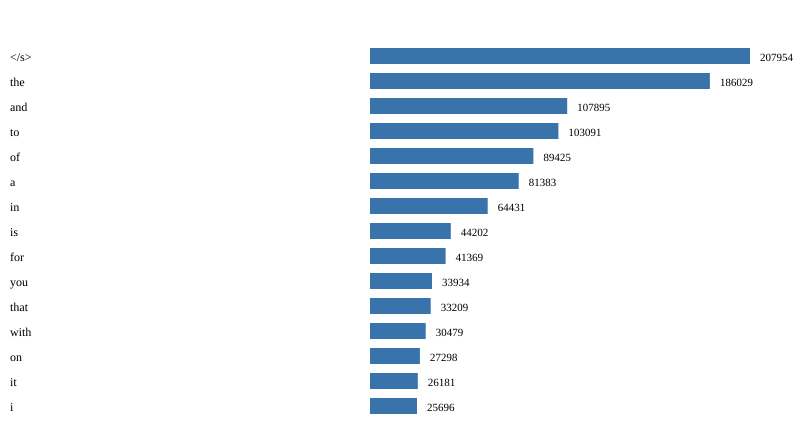

In [6]:
def show_frequency_chart(n, name, filename):
    top = count_ngrams(all_sentences, n).most_common(15)
    max_count = max((count for _, count in top), default=1)
    bars = []
    for index, (gram, count) in enumerate(top):
        y = 48 + index * 25
        full_label = ' '.join(gram)
        label = escape(full_label if len(full_label) <= 34 else full_label[:31] + '...')
        width = 380 * count / max_count
        bars.append(
            f'<text x="10" y="{y + 13}" font-size="12">'
            f'<title>{escape(full_label)}: {count}</title>{label}</text>'
            f'<rect x="370" y="{y}" width="{width:.1f}" height="16" fill="#3973ac"/>'
            f'<text x="{width + 380:.1f}" y="{y + 13}" font-size="11">{count}</text>'
        )
    height = 55 + len(top) * 25
    svg = (
        f'<svg xmlns="http://www.w3.org/2000/svg" role="img" '
        f'aria-label="Tần suất {name}" width="800" height="{height}">'
        f'<title>Tần suất {name}</title>'
        + ''.join(bars) + '</svg>'
    )
    (LAB_DIR / filename).write_text(svg, encoding='utf-8')
    display(SVG(data=svg))

show_frequency_chart(1, 'unigram', 'unigram_frequency.svg')


### Phân bố bigram

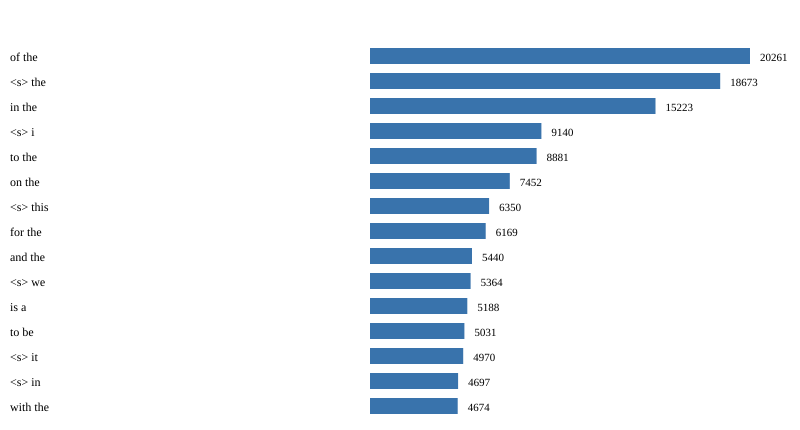

In [7]:
def show_frequency_chart(n, name, filename):
    top = count_ngrams(all_sentences, n).most_common(15)
    max_count = max((count for _, count in top), default=1)
    bars = []
    for index, (gram, count) in enumerate(top):
        y = 48 + index * 25
        full_label = ' '.join(gram)
        label = escape(full_label if len(full_label) <= 34 else full_label[:31] + '...')
        width = 380 * count / max_count
        bars.append(
            f'<text x="10" y="{y + 13}" font-size="12">'
            f'<title>{escape(full_label)}: {count}</title>{label}</text>'
            f'<rect x="370" y="{y}" width="{width:.1f}" height="16" fill="#3973ac"/>'
            f'<text x="{width + 380:.1f}" y="{y + 13}" font-size="11">{count}</text>'
        )
    height = 55 + len(top) * 25
    svg = (
        f'<svg xmlns="http://www.w3.org/2000/svg" role="img" '
        f'aria-label="Tần suất {name}" width="800" height="{height}">'
        f'<title>Tần suất {name}</title>'
        + ''.join(bars) + '</svg>'
    )
    (LAB_DIR / filename).write_text(svg, encoding='utf-8')
    display(SVG(data=svg))

show_frequency_chart(2, 'bigram', 'bigram_frequency.svg')


### Phân bố trigram

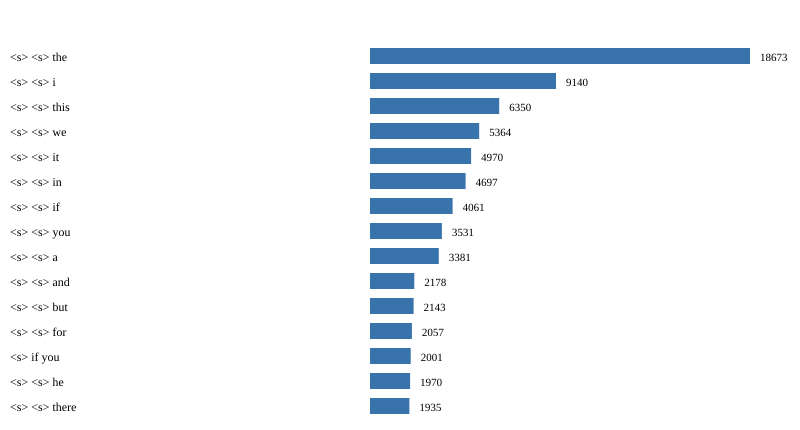

In [8]:
def show_frequency_chart(n, name, filename):
    top = count_ngrams(all_sentences, n).most_common(15)
    max_count = max((count for _, count in top), default=1)
    bars = []
    for index, (gram, count) in enumerate(top):
        y = 48 + index * 25
        full_label = ' '.join(gram)
        label = escape(full_label if len(full_label) <= 34 else full_label[:31] + '...')
        width = 380 * count / max_count
        bars.append(
            f'<text x="10" y="{y + 13}" font-size="12">'
            f'<title>{escape(full_label)}: {count}</title>{label}</text>'
            f'<rect x="370" y="{y}" width="{width:.1f}" height="16" fill="#3973ac"/>'
            f'<text x="{width + 380:.1f}" y="{y + 13}" font-size="11">{count}</text>'
        )
    height = 55 + len(top) * 25
    svg = (
        f'<svg xmlns="http://www.w3.org/2000/svg" role="img" '
        f'aria-label="Tần suất {name}" width="800" height="{height}">'
        f'<title>Tần suất {name}</title>'
        + ''.join(bars) + '</svg>'
    )
    (LAB_DIR / filename).write_text(svg, encoding='utf-8')
    display(SVG(data=svg))

show_frequency_chart(3, 'trigram', 'trigram_frequency.svg')


## Mục 14–19 — Mô hình, smoothing và perplexity

### Huấn luyện mô hình

In [9]:
models = {}
for n in (1, 2, 3):
    mle_model = NGramLanguageModel(n, smoothing='mle').fit(splits['train'])
    models[(n, 'mle')] = mle_model
    if n in (2, 3):
        models[(n, 'laplace')] = mle_model.with_smoothing('laplace')

display(pd.DataFrame([
    {'Mô hình': f'{n}-gram', 'Làm mượt': smoothing,
     'Vocabulary': len(model.vocabulary),
     'N-gram trong train': len(model.ngram_counts)}
    for (n, smoothing), model in models.items()
]))


,Mô hình,Làm mượt,Vocabulary,N-gram trong train
0,1-gram,mle,88999,88998
1,2-gram,mle,88999,1030141
2,2-gram,laplace,88999,1030141
3,3-gram,mle,88999,2136945
4,3-gram,laplace,88999,2136945


### N-gram chưa gặp

In [10]:
unseen_rows = []
for n in (1, 2, 3):
    model = models[(n, 'mle')]
    for split_name, sentences in splits.items():
        mapped = [
            [token if token in model.vocabulary else '<unk>' for token in sentence]
            for sentence in sentences
        ]
        split_counts = count_ngrams(mapped, n)
        unseen = {gram: count for gram, count in split_counts.items()
                  if gram not in model.ngram_counts}
        unseen_rows.append({
            'Mô hình': f'{n}-gram',
            'Tập dữ liệu': split_name,
            'N-gram chưa gặp': len(unseen),
            'Tổng lần chưa gặp': sum(unseen.values()),
        })
        del mapped, split_counts, unseen
display(pd.DataFrame(unseen_rows))


,Mô hình,Tập dữ liệu,N-gram chưa gặp,Tổng lần chưa gặp
0,1-gram,train,0,0
1,1-gram,validation,1,11400
2,1-gram,test,1,9740
3,2-gram,train,0,0
4,2-gram,validation,92227,119385
5,2-gram,test,89910,112460
6,3-gram,train,0,0
7,3-gram,validation,244502,267294
8,3-gram,test,241142,258473


### Perplexity của MLE

In [11]:
mle_ppl_rows = [
    {'Mô hình': f'{n}-gram', 'Làm mượt': 'mle', 'Tập dữ liệu': split_name,
     'Perplexity': models[(n, 'mle')].perplexity(sentences)}
    for n in (1, 2, 3)
    for split_name, sentences in splits.items()
]
mle_ppl_table = pd.DataFrame(mle_ppl_rows).pivot(
    index='Mô hình', columns='Tập dữ liệu', values='Perplexity'
).reset_index()
display(mle_ppl_table)


Tập dữ liệu,Mô hình,test,train,validation
0,1-gram,inf,1651.361405,inf
1,2-gram,inf,120.112748,inf
2,3-gram,inf,9.376607,inf


### So sánh MLE và Laplace

In [12]:
laplace_rows = [
    {'Mô hình': f'{n}-gram', 'Làm mượt': 'laplace',
     'Tập dữ liệu': split_name,
     'Perplexity': models[(n, 'laplace')].perplexity(sentences)}
    for n in (2, 3)
    for split_name, sentences in splits.items()
]
ppl_rows = mle_ppl_rows + laplace_rows
ppl_table = pd.DataFrame(ppl_rows).pivot(
    index=['Mô hình', 'Làm mượt'], columns='Tập dữ liệu', values='Perplexity'
).reset_index()
display(ppl_table)


Tập dữ liệu,Mô hình,Làm mượt,test,train,validation
0,1-gram,mle,inf,1651.361405,inf
1,2-gram,laplace,7.511230e+03,5554.695476,7.918220e+03
2,2-gram,mle,inf,120.112748,inf
3,3-gram,laplace,3.845350e+04,21883.636476,3.902229e+04
4,3-gram,mle,inf,9.376607,inf


**Nhận xét:** MLE có perplexity train giảm mạnh khi context dài hơn (unigram → bigram → trigram), nhưng validation/test có n-gram chưa thấy nên perplexity thành vô hạn. Laplace giúp các xác suất khác 0; tuy vậy perplexity validation/test vẫn cao và trigram Laplace cao hơn bigram Laplace. Đây là dấu hiệu sparsity: tăng context làm số n-gram phân biệt tăng và số liệu cho thấy phần lớn trigram chỉ xuất hiện một lần. Training fit tốt hơn không đảm bảo tổng quát hóa tốt hơn.

## Mục 20 và 22 — Dự đoán từ tiếp theo và phân tích lỗi

In [13]:
trigram = models[(3, 'mle')]
predictions = []
for sentence in splits['test']:
    if len(sentence) < 4:
        continue
    context, actual = sentence[:2], sentence[2]
    prediction = trigram.predict_next(context, top_k=1)
    if not prediction:
        continue
    word, probability = prediction[0]
    predictions.append({
        'Ngữ cảnh': ' '.join(context),
        'Dự đoán': word,
        'Từ thực tế': actual,
        'Xác suất': probability,
        'Đúng': word == actual,
    })
    if sum(item['Đúng'] for item in predictions) >= 2 and \
            sum(not item['Đúng'] for item in predictions) >= 2:
        break
display(pd.DataFrame(predictions))


,Ngữ cảnh,Dự đoán,Từ thực tế,Xác suất,Đúng
0,wall mounted,artwork,with,0.166667,False
1,side and,the,top,0.125000,False
2,not in,the,alpine,0.270833,False
3,you enter,into,the,0.263158,False
4,this stunning,2,20,0.142857,False
5,a few,of,large,0.067219,False
6,a dirt,road,road,0.666667,True
7,the previous,year,owner,0.056000,False
8,this is,a,ideal,0.202417,False
9,award winning,documentary,vineyards,0.038961,False


Các lỗi chủ yếu đến từ n-gram chưa từng gặp, context quá cụ thể và dữ liệu huấn luyện không đủ bao phủ cách diễn đạt trong test. Với ngữ cảnh chưa có trong train, trigram MLE không thể đưa ra dự đoán; ví dụ trong notebook được chọn từ các context có phân phối đã quan sát. Đây là ví dụ của domain mismatch và sparsity của corpus web.

## Mục 21 — Xếp hạng câu tiếp nối

In [14]:
ranking_model = models[(3, 'laplace')]
ranking_context = ['machine', 'learning']
ranking_rows = [
    {'Ứng viên': label, 'Tiếp nối': continuation,
     'Log probability': ranking_model.continuation_log_probability(
         ranking_context, continuation)}
    for label, continuation in {
        'A': 'is useful for nlp',
        'B': 'banana computer quickly',
        'C': 'studies language models',
    }.items()
]
ranking_table = pd.DataFrame(ranking_rows).sort_values(
    'Log probability', ascending=False
).reset_index(drop=True)
display(ranking_table)


,Ứng viên,Tiếp nối,Log probability
0,B,banana computer quickly,-34.189602
1,C,studies language models,-34.189602
2,A,is useful for nlp,-43.188907


## Mục 23 — Ảnh hưởng của độ dài context

### Bảng tổng hợp context length

In [15]:
context_rows = []
for n in (1, 2, 3):
    unseen_validation = next(
        row['N-gram chưa gặp'] for row in unseen_rows
        if row['Mô hình'] == f'{n}-gram' and row['Tập dữ liệu'] == 'validation'
    )
    unseen_test = next(
        row['N-gram chưa gặp'] for row in unseen_rows
        if row['Mô hình'] == f'{n}-gram' and row['Tập dữ liệu'] == 'test'
    )
    context_rows.append({
        'Mô hình': f'{n}-gram',
        'N-gram phân biệt train': len(models[(n, 'mle')].ngram_counts),
        'Perplexity train': next(row['Perplexity'] for row in mle_ppl_rows if row['Mô hình'] == f'{n}-gram' and row['Tập dữ liệu'] == 'train'),
        'Perplexity validation': next(row['Perplexity'] for row in mle_ppl_rows if row['Mô hình'] == f'{n}-gram' and row['Tập dữ liệu'] == 'validation'),
        'N-gram chưa gặp validation': unseen_validation,
        'Perplexity test': next(row['Perplexity'] for row in mle_ppl_rows if row['Mô hình'] == f'{n}-gram' and row['Tập dữ liệu'] == 'test'),
        'N-gram chưa gặp test': unseen_test,
    })
context_table = pd.DataFrame(context_rows)
display(context_table)


,Mô hình,N-gram phân biệt train,Perplexity train,Perplexity validation,N-gram chưa gặp validation,Perplexity test,N-gram chưa gặp test
0,1-gram,88998,1651.361405,inf,1,inf,1
1,2-gram,1030141,120.112748,inf,92227,inf,89910
2,3-gram,2136945,9.376607,inf,244502,inf,241142


## Lưu kết quả

In [16]:
result_rows = []
for row in corpus_stats:
    result_rows.append({'type': 'corpus_stat', 'metric': row['Chỉ số'],
                        'value': row['Giá trị']})
for row in ngram_rows:
    for key in ('Tổng n-gram', 'N-gram phân biệt', 'Chỉ xuất hiện một lần'):
        result_rows.append({'type': 'ngram_stat', 'model': row['Mô hình'],
                            'metric': key, 'value': row[key]})
for row in unseen_rows:
    for key in ('N-gram chưa gặp', 'Tổng lần chưa gặp'):
        result_rows.append({'type': 'unseen_ngram', 'model': row['Mô hình'],
                            'split': row['Tập dữ liệu'], 'metric': key,
                            'value': row[key]})
for row in ppl_rows:
    result_rows.append({'type': 'perplexity', 'model': row['Mô hình'],
                        'smoothing': row['Làm mượt'], 'split': row['Tập dữ liệu'],
                        'value': row['Perplexity']})
for row in predictions:
    result_rows.append({'type': 'next_word', **row})
for row in ranking_rows:
    result_rows.append({'type': 'sentence_ranking', 'context': 'machine learning',
                        'candidate': row['Ứng viên'], 'continuation': row['Tiếp nối'],
                        'value': row['Log probability']})

result_path = LAB_DIR / 'results.csv'
with result_path.open('w', newline='', encoding='utf-8') as stream:
    fieldnames = sorted({key for row in result_rows for key in row})
    writer = csv.DictWriter(stream, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(result_rows)
display(pd.DataFrame([{'Tệp kết quả': result_path.name,
                       'Số dòng dữ liệu': len(result_rows)}]))


,Tệp kết quả,Số dòng dữ liệu
0,results.csv,60
